The following notebook contains a brief tutorial on optuna, hyperparameter tuning and supervised learning. As a motivation for this we analyze a public dataset that contains Danish AIS data. AIS (Automatic Identification System) is an RF beacon system that identifies ships, their position, heading and other relevant information when they are sailing out at sea. Given its open nature anyone with an AIS receiver can collect data from passing ships if they are transmitting. This information is used for maratime safety and compliance to international and national law. Some ships turn off their AIS either during military operations, high risk areas and for illegal activities. These vessels are known popularly as dark vessels. 

Using this dataset the objective will be to use several data fields to predict the class of ship. Additionally using a subset of the dataset we will attempt to develop a classifier that can determine when a fishing vessel is fishing. To accomplish these objectives we will use several fairly standard python libraries for machine learning

In [1]:
import pandas as pd

Pandas is a library that allows us to import csv files and manipulate data efficiently structured as dataframes.

In [2]:
import matplotlib.pyplot as plt

Matplotlib is probably the most popular python visualization package and can be used to make a wide variety of graphs and basic diagrams. We will use it to visualize the results of our classifiers

In [3]:
import torch

PyTorch is a fundemental machine learning library in python (though is mostly written in c++ for speed). Most of libraries that are at a higher level of abstraction use pytorch to implement key components. Pytorch can be used to implement custom neural network architectures and trained models can be relatively easily exported to c++. 

In [4]:
import sklearn

Scikit-Learn is a machine learning library that frequently used to conduct older machine learning algorithms such as support vector machines and unsupervised learning techniques such as k-means. This library is great for quick implementations as it requires very little code for supervised and supervised learning cases. It also provides solid baselines for comparison, if you are trying to determine if a new approach you are working on is suitable or not. sklearn also has some pretty useful tools for setting up your datasets in a supervised learning scenario (training,validation and testing sets)

To start we will import the csv file using the pandas library to acquire the AIS data and we will conduct a couple visualizations to get a better idea of what data is stored. 

In [5]:
Complete_dataset=pd.read_csv('ais_data.csv')
print(Complete_dataset)

        Unnamed: 0       mmsi      navigationalstatus   sog    cog  heading  \
0                0  219019621           Unknown value   0.0   86.0     86.0   
1                1  265628170           Unknown value   0.0  334.5      NaN   
2                2  219005719           Unknown value   0.0  208.7      NaN   
3                3  219028066           Unknown value   0.0    NaN      NaN   
4                4  212584000                  Moored   0.0  153.0    106.0   
...            ...        ...                     ...   ...    ...      ...   
358346      387577  236125000  Under way using engine  11.0  171.9    169.0   
358347      387578  209717000  Under way using engine  16.6  341.6    343.0   
358348      387579  257182000  Under way using engine  20.6  340.7    341.0   
358349      387580  219007697           Unknown value  34.9   96.2      NaN   
358350      387581  261054050  Under way using engine  11.5  315.0    310.0   

           shiptype  width  length  draught  
0    

In this tabular dataset we have many data fields (i.e features). Some data fields are not always filled or have a placeholder value such as "unknown". 
The data fields are as follows:
mmsi:This is an id for a specific vessel
navigational status: Vessels provide what maratime activities they are conducting, especially if they limit their maneuvrability (fishing)

sog:speed over ground in (knots)

cog:course over ground (degrees), where the boat is going

heading: Direction the ship is pointing

shiptype:Type of ship that is transmitting

width: Width of the ship (how wide it is)

length: Length of the ship

draught: How deep in the water the ship extends (important for navigation)



([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16],
 [Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, '')])

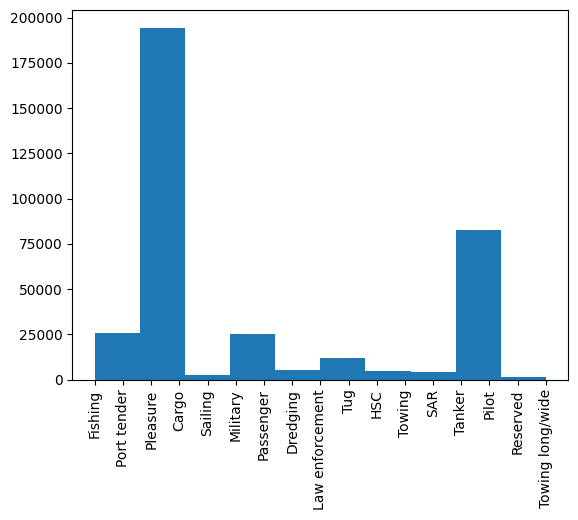

In [6]:
shiptype=Complete_dataset['shiptype']
plt.hist(shiptype)
plt.xticks(rotation='vertical')

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
 [Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, '')])

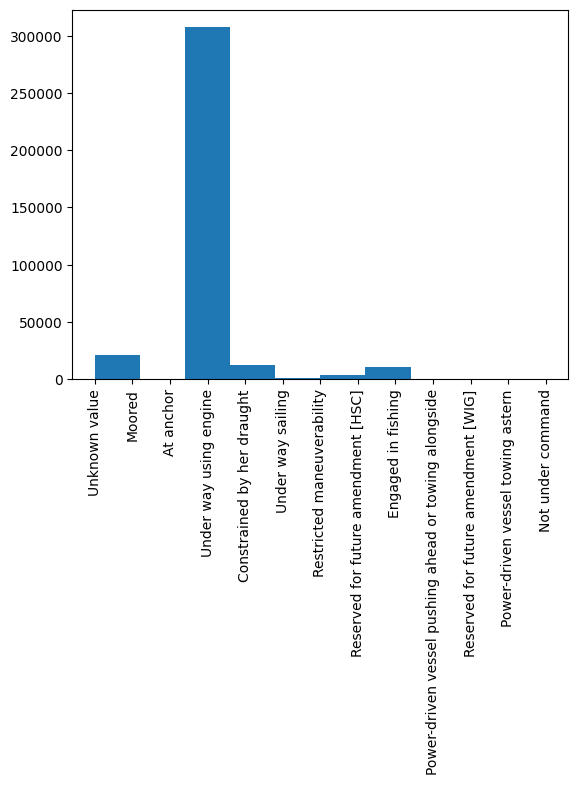

In [7]:
navstat=Complete_dataset['navigationalstatus']
plt.hist(navstat)
plt.xticks(rotation='vertical')

In [8]:
#mmsi analysis
#Time series analysis

        Unnamed: 0       mmsi      navigationalstatus   sog    cog  heading  \
0                0  219019621           Unknown value   0.0   86.0     86.0   
2                2  219005719           Unknown value   0.0  208.7      NaN   
6                6  219006116           Unknown value   0.0    0.0      NaN   
9                9  219003138           Unknown value   0.0    0.0      NaN   
17              17  219014192           Unknown value   0.0  224.1      NaN   
...            ...        ...                     ...   ...    ...      ...   
358320      387551  219012671      Engaged in fishing   7.7  327.3    328.0   
358325      387556  219012671      Engaged in fishing   7.7  323.8    326.0   
358340      387571  261054050  Under way using engine  11.1  338.0    335.0   
358344      387575  266332000      Engaged in fishing   9.0  318.5    318.0   
358350      387581  261054050  Under way using engine  11.5  315.0    310.0   

       shiptype  width  length  draught  
0       F

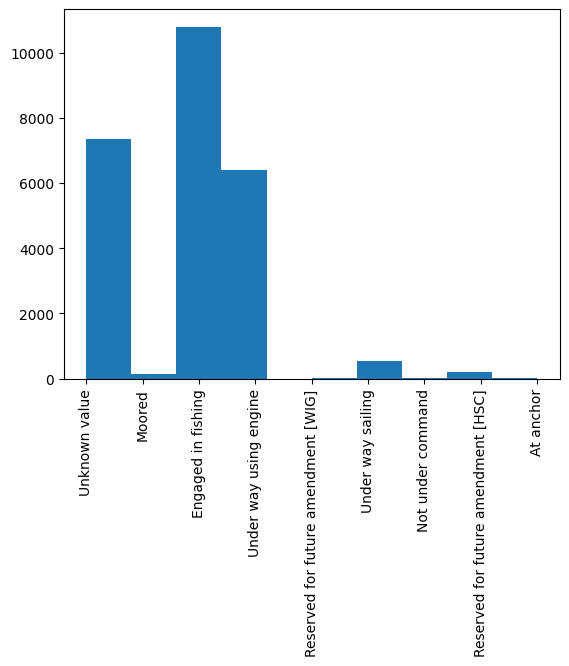

In [9]:
#fishing dataset
fishing_dataset = Complete_dataset.loc[Complete_dataset['shiptype'] == 'Fishing']
print(fishing_dataset)
#Next we determine the class distribution of the 
fishing_navigational_status=fishing_dataset['navigationalstatus']
plt.hist(fishing_navigational_status)
plt.xticks(rotation='vertical')
plt.show()


In [10]:
#Data preprocessing
#Need to modify data for input into machine learning algorithms
#Need to convert text values into classes and handle the discrete nature of mmsi
#Normalize continuous values
#To normalize the values we will use the maximum values for each of the numeric columns
max_length=Complete_dataset["length"].max()
max_draught=Complete_dataset["draught"].max()
max_width=Complete_dataset["width"].max()
cog_max=360
heading_max=360
sog_max=Complete_dataset["sog"].max()
#Next we use these values to keep values between 0 and 1. This is important for many ML techniques as 
Complete_dataset["length"]=Complete_dataset["length"]/max_length
Complete_dataset["draught"]=Complete_dataset["draught"]/max_draught
Complete_dataset["width"]=Complete_dataset["width"]/max_width
Complete_dataset["cog"]=Complete_dataset["cog"]/cog_max
Complete_dataset["heading"]=Complete_dataset["heading"]/heading_max
Complete_dataset["sog"]=Complete_dataset["sog"]/sog_max
Complete_dataset = Complete_dataset.fillna(0)
print(Complete_dataset)

        Unnamed: 0       mmsi      navigationalstatus       sog       cog  \
0                0  219019621           Unknown value  0.000000  0.238889   
1                1  265628170           Unknown value  0.000000  0.929167   
2                2  219005719           Unknown value  0.000000  0.579722   
3                3  219028066           Unknown value  0.000000  0.000000   
4                4  212584000                  Moored  0.000000  0.425000   
...            ...        ...                     ...       ...       ...   
358346      387577  236125000  Under way using engine  0.051402  0.477500   
358347      387578  209717000  Under way using engine  0.077570  0.948889   
358348      387579  257182000  Under way using engine  0.096262  0.946389   
358349      387580  219007697           Unknown value  0.163084  0.267222   
358350      387581  261054050  Under way using engine  0.053738  0.875000   

         heading     shiptype     width    length   draught  
0       0.238

In [11]:
#Next One hot encoding
navigational_status_values={"Unknown value":0,"Moored":1,"Engaged in fishing":2, "Under way using engine":3,"Reserved for future amendment [WIG]":4,"Under way sailing":5,"Not under command":6,"Reserved for future amendment [HSC]":7,"At anchor":8}
Complete_dataset["navigationalstatus"] = pd.Categorical(
    Complete_dataset["navigationalstatus"],
    categories=navigational_status_values.keys()
)

one_hot = pd.get_dummies(Complete_dataset["navigationalstatus"], prefix="nav_status")
Complete_dataset = pd.concat([Complete_dataset, one_hot], axis=1)
print(Complete_dataset)
#Save the converted dataset for later
Complete_dataset.to_csv("Cleaned_AIS_Dataset.csv")
one_hot.to_csv("One_Hot.csv")


        Unnamed: 0       mmsi      navigationalstatus       sog       cog  \
0                0  219019621           Unknown value  0.000000  0.238889   
1                1  265628170           Unknown value  0.000000  0.929167   
2                2  219005719           Unknown value  0.000000  0.579722   
3                3  219028066           Unknown value  0.000000  0.000000   
4                4  212584000                  Moored  0.000000  0.425000   
...            ...        ...                     ...       ...       ...   
358346      387577  236125000  Under way using engine  0.051402  0.477500   
358347      387578  209717000  Under way using engine  0.077570  0.948889   
358348      387579  257182000  Under way using engine  0.096262  0.946389   
358349      387580  219007697           Unknown value  0.163084  0.267222   
358350      387581  261054050  Under way using engine  0.053738  0.875000   

         heading     shiptype     width    length   draught  \
0       0.23

In [12]:
#Need to determine the number of mmsi values
import torch.nn as nn
Complete_dataset["mmsi"] = Complete_dataset["mmsi"].astype("category").cat.codes
num_vessels = Complete_dataset["mmsi"].nunique()
print(num_vessels)

embedding_dim = 16

embedding = nn.Embedding(num_vessels, embedding_dim)
#Cleaned up Dataset
mmsi_column=Complete_dataset['mmsi']
sog_column=Complete_dataset['sog']
cog_column=Complete_dataset['cog']
heading_column=Complete_dataset['heading']
length_column=Complete_dataset['length']
width_column=Complete_dataset['width']
draught_column=Complete_dataset['draught']
#Next the navigational status one hot encoding
feature_dataset=pd.concat([sog_column,cog_column,heading_column,length_column,width_column,draught_column,one_hot],axis=1)
print(feature_dataset)

3894
             sog       cog   heading    length     width   draught  \
0       0.000000  0.238889  0.238889  0.013043  0.051282  0.000000   
1       0.000000  0.929167  0.000000  0.039130  0.102564  0.000000   
2       0.000000  0.579722  0.000000  0.015942  0.051282  0.000000   
3       0.000000  0.000000  0.000000  0.017391  0.038462  0.000000   
4       0.000000  0.425000  0.294444  0.143478  0.166667  0.247059   
...          ...       ...       ...       ...       ...       ...   
358346  0.051402  0.477500  0.469444  0.118841  0.153846  0.164706   
358347  0.077570  0.948889  0.952778  0.246377  0.346154  0.349020   
358348  0.096262  0.946389  0.947222  0.324638  0.461538  0.270588   
358349  0.163084  0.267222  0.000000  0.010145  0.038462  0.000000   
358350  0.053738  0.875000  0.861111  0.046377  0.102564  0.235294   

        nav_status_Unknown value  nav_status_Moored  \
0                              1                  0   
1                              1            

In [13]:
#Next we need to define a basic model to input this 
class Model(nn.Module):
    def __init__(self, num_vessels, embedding_dim, num_numeric_features):
        super().__init__()

        self.mmsi_embed = nn.Embedding(
            num_embeddings=num_vessels,
            embedding_dim=embedding_dim
        )

        self.input_dim = embedding_dim + num_numeric_features 
        
        self.fc1 = nn.Linear(self.input_dim, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 32)
        self.fc4 = nn.Linear(32, 17)
        
    def forward(self, mmsi, numeric_features):
        mmsi_emb = self.mmsi_embed(mmsi).squeeze(1)
        #print("mmsi_emb.shape:", mmsi_emb.shape)
        #print("numeric_features.shape:", numeric_features.shape)
        x = torch.cat([mmsi_emb, numeric_features], dim=1)
        #print("x.shape after concat:", x.shape)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = torch.relu(self.fc3(x))
        x = self.fc4(x) 
        return x

In [14]:
#We use sklearn to divide the datasets into training, validation and testing
shipType=Complete_dataset['shiptype']
print(shipType)
import sklearn as sk
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import TensorDataset, DataLoader

mmsi_data=Complete_dataset['mmsi']
mmsi_encoder = LabelEncoder()
mmsi_encoded = mmsi_encoder.fit_transform(Complete_dataset['mmsi'])
X_mmsi_train, X_mmsi_test, \
X_num_train, X_num_test, \
y_train, y_test = sk.model_selection.train_test_split(
    mmsi_encoded,
    feature_dataset,
    shipType,
    test_size=0.1,
    shuffle=False
)

X_mmsi_train, X_mmsi_val, \
X_num_train, X_num_val, \
y_train, y_val = sk.model_selection.train_test_split(
    X_mmsi_train,
    X_num_train,
    y_train,
    test_size=0.1,
    shuffle=False
)
le = LabelEncoder()

y_train_enc = le.fit_transform(y_train)
y_val_enc   = le.transform(y_val)
#Next we need to feed these into the basic pytorch model

X_mmsi_train_t = torch.tensor(X_mmsi_train, dtype=torch.long)
X_mmsi_val_t   = torch.tensor(X_mmsi_val, dtype=torch.long)

X_num_train_t = torch.tensor(X_num_train.to_numpy(), dtype=torch.float32)
X_num_val_t   = torch.tensor(X_num_val.to_numpy(), dtype=torch.float32)

y_train_t = torch.tensor(y_train_enc, dtype=torch.long)
y_val_t   = torch.tensor(y_val_enc, dtype=torch.long)
train_dataset = TensorDataset(
    X_mmsi_train_t,
    X_num_train_t,
    y_train_t
)

val_dataset = TensorDataset(
    X_mmsi_val_t,
    X_num_val_t,
    y_val_t
)

train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=False)
val_dataloader   = DataLoader(val_dataset, batch_size=32, shuffle=False)




0             Fishing
1         Port tender
2             Fishing
3            Pleasure
4               Cargo
             ...     
358346          Cargo
358347          Cargo
358348      Passenger
358349          Pilot
358350        Fishing
Name: shiptype, Length: 358351, dtype: object


2754.2395253912546
Epoch 1/10, Loss: 0.3036
Val Accuracy: 81.34%
521.1401496289109
Epoch 2/10, Loss: 0.0575
Val Accuracy: 85.56%
221.48025156389622
Epoch 3/10, Loss: 0.0244
Val Accuracy: 88.93%
115.71365305883407
Epoch 4/10, Loss: 0.0128
Val Accuracy: 89.56%
70.99857574511348
Epoch 5/10, Loss: 0.0078
Val Accuracy: 90.75%
56.58391110211839
Epoch 6/10, Loss: 0.0062
Val Accuracy: 91.47%
39.35008507384342
Epoch 7/10, Loss: 0.0043
Val Accuracy: 91.28%
31.231569694271776
Epoch 8/10, Loss: 0.0034
Val Accuracy: 91.64%
30.278897247999037
Epoch 9/10, Loss: 0.0033
Val Accuracy: 90.67%
27.123504408527488
Epoch 10/10, Loss: 0.0030
Val Accuracy: 91.80%
Finished Training


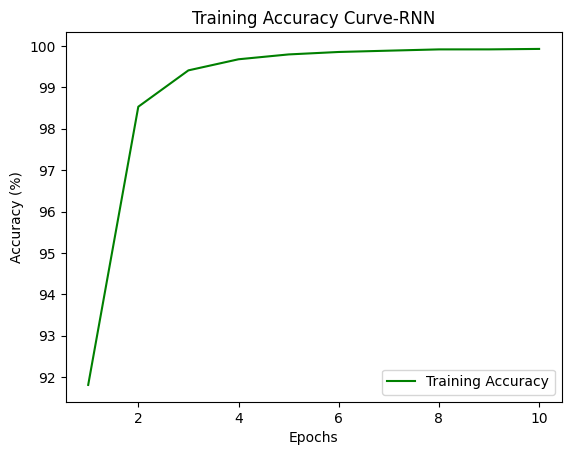

ValueError: x and y must have same first dimension, but have shapes (10,) and (1,)

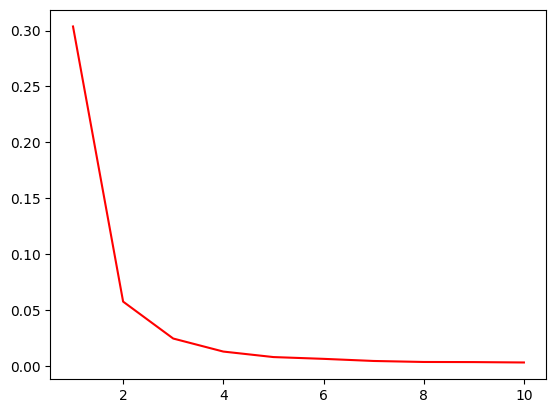

In [15]:
training_epochs=10
num_vessels = len(mmsi_encoder.classes_)
assert X_mmsi_train_t.min() >= 0
assert X_mmsi_train_t.max() < num_vessels
assert X_mmsi_val_t.min() >= 0
assert X_mmsi_val_t.max() < num_vessels
net_nn=Model(num_vessels,16,15)
optimizer = torch.optim.Adam(net_nn.parameters(), lr=1e-3)
train_losses=[]
accuracies=[]
for epoch in range(training_epochs):  
    running_loss = 0.0
    net_nn.train()
    train_accuracy=0
    train_total=0
    train_correct=0
    for mmsi, numeric, labels in train_dataloader:
        optimizer.zero_grad()
        outputs = net_nn(mmsi,numeric)
        labels = labels.long()
        criterion=nn.CrossEntropyLoss()
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        predicted = outputs.argmax(dim=1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()
        running_loss += loss.item()
    print(running_loss)
    train_losses.append(running_loss/len(train_dataloader))
    print(f"Epoch {epoch+1}/{training_epochs}, Loss: {running_loss/len(train_dataloader):.4f}")
    train_accuracy = 100 * train_correct / train_total
    accuracies.append(train_accuracy)
    all_val_labels = []
    all_val_predictions = []
    val_total=0
    val_correct=0
    val_accuracy=0
    val_losses=[]
    with torch.no_grad():
        val_total=0
        val_correct=0
        val_accuracy=0
        running_loss=0.0
        for mmsi, numeric, labels in val_dataloader:
            net_nn.eval()
            outputs = net_nn(mmsi,numeric) 
            labels = labels.long()
            predicted = outputs.argmax(dim=1)
            all_val_labels.extend(labels.cpu().numpy())
            all_val_predictions.extend(predicted.cpu().numpy())
            val_total += labels.size(0)
            running_loss += loss.item()
            val_correct += (predicted == labels).sum().item()
        val_accuracy = 100 * val_correct / val_total
        val_losses.append(running_loss/len(val_dataloader))
    print(f"Val Accuracy: {val_accuracy:.2f}%")
    #cm_val = confusion_matrix(all_val_labels, all_val_predictions)
    #print(f"F1 Score:{f1_score(all_val_labels,all_val_predictions):.2f}%")
    # Plot confusion matrix
    #plt.figure(figsize=(6, 5))
    #sns.heatmap(cm_val, annot=True, fmt='d', cmap="Blues", xticklabels=range(len(cm_val)), yticklabels=range(len(cm_val)))
    #plt.xlabel('Predicted Label')
    #plt.ylabel('True Label')
    #plt.title('Confusion Matrix RNN')
    #plt.savefig('conf_matrix_rnn_val.png')
    #plt.show()
print('Finished Training')
#Next we evaluate the RNN model quickly
plt.plot(range(1, training_epochs + 1), accuracies, label="Training Accuracy", color="green")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.title("Training Accuracy Curve-RNN")
plt.legend()
plt.savefig('accuracy_graph_rnn.png')
plt.show()
plt.plot(range(1, training_epochs + 1), train_losses, label="Training Loss", color="red")
plt.plot(range(1, training_epochs + 1), val_losses, label="Validation Loss", color="green")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Validation Loss Curve")
plt.legend()
plt.savefig('Loss_graph_RNN.png')
plt.show()
#Next we need to add testing accuracy and confusion matrix to this analysis
net_rnn.eval()
correct = 0
total = 0
all_val_labels = []
all_val_predictions = []
with torch.no_grad():
    for inputs, labels in test_dataloader:
        outputs = net_rnn(inputs) 
        labels = labels.float().view(-1, 1)
        predicted = (torch.sigmoid(outputs) >= 0.5).float()   
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")
accuracy_values.append(accuracy)

In [ ]:
#Model Definition
#Define the transformer, RNN and NN architectures
X_train = X_train.apply(pd.to_numeric, errors='coerce') 
X_val=X_val.apply(pd.to_numeric, errors='coerce') 
X_test = X_test.apply(pd.to_numeric, errors='coerce')
X_train_np = X_train.to_numpy(dtype=np.float32)
X_test_np = X_test.to_numpy(dtype=np.float32)
X_val_np=X_val.to_numpy(dtype=np.float32)
print(y_train)
print(y_test)
print(y_val)
label_encode=LabelEncoder()
y_train=label_encode.fit_transform(y_train)
y_test=label_encode.transform(y_test)
y_val=label_encode.transform(y_val)
X_train_tensor = torch.tensor(X_train_np)
y_train_tensor = torch.tensor(y_train)
X_test_tensor = torch.tensor(X_test_np)
y_test_tensor = torch.tensor(y_test)
X_val_tensor=torch.tensor(X_val_np)
y_val_tensor=torch.tensor(y_val)
print(X_val_tensor)
print(y_val_tensor)
class Dataset_conv(Dataset):
    def __init__(self, X, y):
        self.X= X
        self.y =y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

training_dataset = Dataset_conv(X_train_tensor, y_train_tensor)
test_data = Dataset_conv(X_test_tensor, y_test_tensor)
val_data=Dataset_conv(X_val_tensor,y_val_tensor)
train_dataloader = DataLoader(training_dataset, batch_size=64, shuffle=False)
test_dataloader = DataLoader(test_data, shuffle=False)
val_dataloader=DataLoader(val_data,batch_size=64,shuffle=False)
class RNN_net(torch.nn.Module):
    def __init__(self):
        super().__init__()
        #Layers below
        self.rnn1 =nn.RNN(5,256,2)
        self.fc1 = nn.Linear(256,128)
        self.fc2=nn.Linear(128, 1)
    def forward(self, x):
        output, hidden = self.rnn1(x) 
        x = torch.tanh(output) 
        x = F.relu(self.fc1(x)) 
        x = self.fc2(x) 
        return x  

class Transformer_Model(torch.nn.Module):
    def __init__(self):
        super().__init__()
        #We need to consider the embedding for mmsi

        #Next input layer

        #Next transformer layer

    def forward(self,x):
        mmsi=
        output=self.embed1(mmsi)
        output=
        x=
        return x

        
        

In [ ]:
#Baseline Definitions

In [ ]:
#Initial Results
net_transformer= Transformer_Model()
criterion = nn.
optimizer = optim.Adam(net_transformer.parameters(), lr=0.0001)
training_epochs=25
accuracies = []
train_total=0
train_correct=0
val_total=0
val_correct=0
count=0
val_losses=[]
train_losses=[]
for epoch in range(training_epochs):  
    running_loss = 0.0
    net_rnn.train()
    train_accuracy=0
    train_total=0
    train_correct=0
    for inputs, labels in train_dataloader:
        optimizer.zero_grad()
        outputs = net_rnn(inputs)
        labels = labels.float().view(-1, 1)
        loss = criterion(torch.sigmoid(outputs), labels)
        loss.backward()
        optimizer.step()
        predicted =(torch.sigmoid(outputs) >= 0.5).float()   
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()
        running_loss += loss.item()
    train_losses.append(running_loss/len(train_dataloader))
    print(f"Epoch {epoch+1}/{training_epochs}, Loss: {running_loss/len(train_dataloader):.4f}")
    train_accuracy = 100 * train_correct / train_total
    accuracies.append(train_accuracy)
    all_val_labels = []
    all_val_predictions = []
    val_total=0
    val_correct=0
    val_accuracy=0
    with torch.no_grad():
        val_total=0
        val_correct=0
        val_accuracy=0
        running_loss=0.0
        for inputs,labels in val_dataloader:
            net_rnn.eval()
            outputs = net_rnn(inputs) 
            labels = labels.float().view(-1, 1)
            predicted = (torch.sigmoid(outputs) >= 0.5).float()
            all_val_labels.extend(labels.cpu().numpy())
            all_val_predictions.extend(predicted.cpu().numpy())
            val_total += labels.size(0)
            running_loss += loss.item()
            val_correct += (predicted == labels).sum().item()
        val_accuracy = 100 * val_correct / val_total
        val_losses.append(running_loss/len(val_dataloader))
    print(f"Val Accuracy: {val_accuracy:.2f}%")
    cm_val = confusion_matrix(all_val_labels, all_val_predictions)
    print(f"F1 Score:{f1_score(all_val_labels,all_val_predictions):.2f}%")
    # Plot confusion matrix
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm_val, annot=True, fmt='d', cmap="Blues", xticklabels=range(len(cm_val)), yticklabels=range(len(cm_val)))
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix RNN')
    plt.savefig('conf_matrix_rnn_val.png')
    plt.show()
print('Finished Training')
#Next we evaluate the RNN model quickly
plt.plot(range(1, training_epochs + 1), accuracies, label="Training Accuracy", color="green")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.title("Training Accuracy Curve-RNN")
plt.legend()
plt.savefig('accuracy_graph_rnn.png')
plt.show()
plt.plot(range(1, training_epochs + 1), train_losses, label="Training Loss", color="red")
plt.plot(range(1, training_epochs + 1), val_losses, label="Validation Loss", color="green")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Validation Loss Curve")
plt.legend()
plt.savefig('Loss_graph_RNN.png')
plt.show()
#Next we need to add testing accuracy and confusion matrix to this analysis
net_rnn.eval()
correct = 0
total = 0
all_val_labels = []
all_val_predictions = []
with torch.no_grad():
    for inputs, labels in test_dataloader:
        outputs = net_rnn(inputs) 
        labels = labels.float().view(-1, 1)
        predicted = (torch.sigmoid(outputs) >= 0.5).float()   
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")
accuracy_values.append(accuracy)
all_labels = []
all_predictions = []

In [ ]:
#Hyperparameter tuning
import optuna as tune

In [ ]:
def objective(trial):
    
    n_layers = trial.suggest_int('n_layers', 1, 3)
    layers = []

    in_features = 28 * 28
    for i in range(n_layers):
        out_features = trial.suggest_int(f'n_units_l{i}', 4, 128)
        layers.append(torch.nn.Linear(in_features, out_features))
        layers.append(torch.nn.ReLU())
        in_features = out_features
    layers.append(torch.nn.Linear(in_features, 10))
    layers.append(torch.nn.LogSoftmax(dim=1))
    model = torch.nn.Sequential(*layers).to(torch.device('cpu'))
    ...
    return accuracy

# 3. Create a study object and optimize the objective function.
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100)

Optuna is a very popular hyperparameter tuning library in python. Hyperparameter tuning can be a make or break in machine learning in terms of performance. Unfortunately, finding the best hyperparameters is very challenging and requires searching a large space of values. 

In [ ]:
#Final Results